## Solar + BESS CAPEX Analysis (Example)

This notebook presents example analyses of solar PV and battery energy storage system (BESS) capital expenditures using dictionary-based inputs.

### 1. CAPEX Sweep

Evaluation of a **200 MW solar PV plant** with a **150 MW inverter**, AC-coupled with BESS across a range of configurations:

- **BESS power capacity:** 10% to 100% of solar MWdc (in 10% increments)  
- **BESS durations:** 2, 4, 8, and 12 hours  

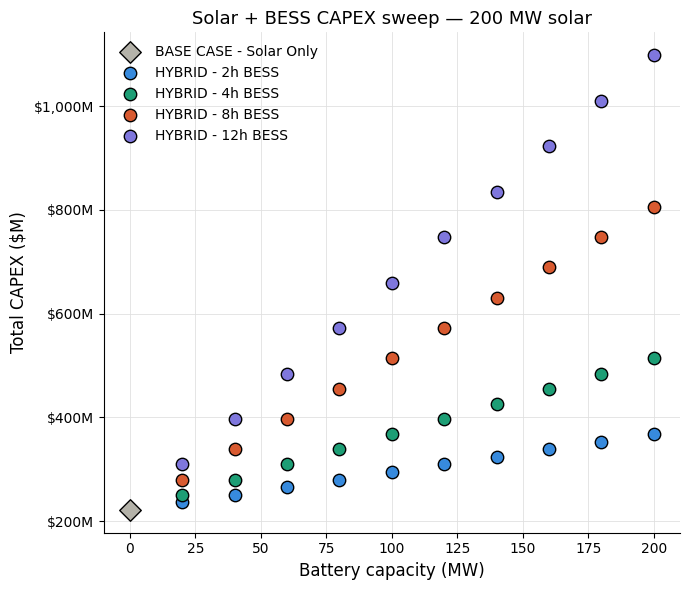

In [1]:
import os
import sys
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ---------------------------------------------------------------------------
# Path setup
# ---------------------------------------------------------------------------
current_dir = os.getcwd()
project_root = current_dir
while project_root != os.path.dirname(project_root):
    if os.path.exists(os.path.join(project_root, "genstor")):
        break
    project_root = os.path.dirname(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

from genstor.runner import CentralRunner

# ---------------------------------------------------------------------------
# Run the sweep (reuses your existing sweep logic)
# ---------------------------------------------------------------------------
SYSTEM_SIZE_KWDC = 200_000          # 200 MW solar (fixed throughout)
ILR              = 1.33333          # 150 MW solar inverter
BESS_MW_RATIOS   = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
BESS_DURATIONS   = [2, 4, 8, 12]
# -- Standalone solar -------------------------------------------------------
standalone_cfg = {
    "project_name": "Standalone Solar",
    "technologies": [{
        "name": "standalone_solar",
        "type": "solar_bess_2024Q1",
        "params": {"SystemSize": SYSTEM_SIZE_KWDC, "ILR": ILR, "IncludeESS": False},
    }],
}
standalone_result  = CentralRunner(standalone_cfg).run().summary()
standalone_capex   = next(iter(standalone_result["capex_by_tech"].values()))["total"]
standalone_capex_m = standalone_capex * SYSTEM_SIZE_KWDC / 1e6   # convert to $M
# -- BESS sweep -------------------------------------------------------------
records = []
for ratio in BESS_MW_RATIOS:
    for dur in BESS_DURATIONS:
        storage_duration = ratio * dur
        bess_mw          = SYSTEM_SIZE_KWDC / 1_000 * ratio
        cfg = {
            "project_name": f"Solar+BESS {bess_mw:.0f}MW {dur}h",
            "technologies": [{
                "name": f"solar_bess_{bess_mw:.0f}mw_{dur}h",
                "type": "solar_bess_2024Q1",
                "params": {
                    "SystemSize":      SYSTEM_SIZE_KWDC,
                    "ILR":             ILR,
                    "StorageDuration": storage_duration,
                    "BatteryDuration": dur,
                    "IncludeESS":      True,
                },
            }],
        }
        result   = CentralRunner(cfg).run().summary()
        capex_kw = next(iter(result["capex_by_tech"].values()))["total"]
        records.append({
            "bess_mw":   bess_mw,
            "duration":  dur,
            "capex_m":   capex_kw * SYSTEM_SIZE_KWDC / 1e6,
        })
# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
duration_colors = {2: "#378ADD", 4: "#1D9E75", 8: "#D85A30", 12: "#7F77DD"}
fig, ax = plt.subplots(figsize=(7, 6))
# Standalone solar — grey diamond at battery_mw = 0
ax.scatter(0, standalone_capex_m, color="#B4B2A9", s=120, marker="D",
           zorder=5, label="BASE CASE - Solar Only", edgecolor = "black")
# BESS combos
for dur in BESS_DURATIONS:
    subset = [r for r in records if r["duration"] == dur]
    ax.scatter(
        [r["bess_mw"]  for r in subset],
        [r["capex_m"]  for r in subset],
        color=duration_colors[dur],
        s=80, zorder=4, label=f"HYBRID - {dur}h BESS",
        edgecolor = "black"
    )
ax.set_xlabel("Battery capacity (MW)", fontsize=12)
ax.set_ylabel("Total CAPEX ($M)", fontsize=12)
ax.set_title("Solar + BESS CAPEX sweep — 200 MW solar", fontsize=13)
ax.legend(frameon=False, fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}M"))
ax.grid(axis="both", color="#e0e0e0", linewidth=0.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
#plt.savefig("solar_bess_capex_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Plot saved to solar_bess_capex_scatter.png")

### 2. CAPEX Breakdown

Detailed CAPEX breakdown for selected configurations:

- **200 MW solar + 60 MW / 2h BESS, 150 MW solar inverter, AC-coupled**  
- **200 MW solar + 120 MW / 4h BESS, 150 MW solar inverter, AC-coupled**  

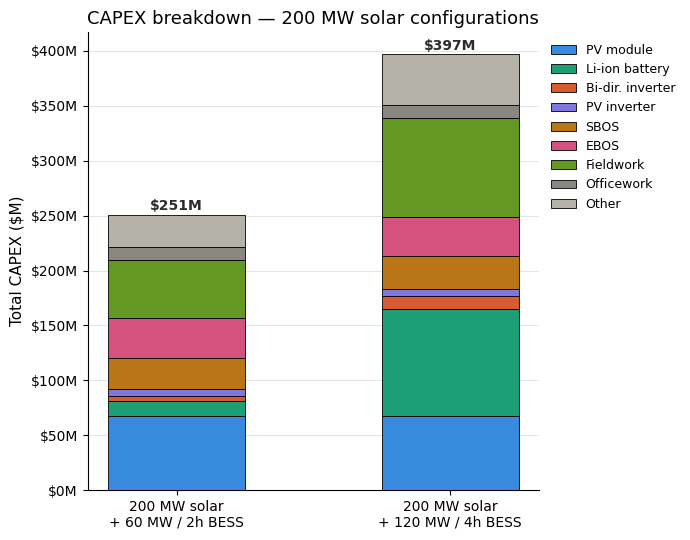

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

SYSTEM_SIZE_KWDC = 200_000          # 200 MW solar (fixed throughout)
ILR              = 1.33333          # 150 MW solar inverter

# ---------------------------------------------------------------------------
# Run both systems
# ---------------------------------------------------------------------------
def run_system(bess_ratio, bess_duration):
    storage_duration = bess_ratio * bess_duration
    cfg = {
        "project_name": f"Solar+BESS",
        "technologies": [{
            "name": "solar_plus_storage",
            "type": "solar_bess_2024Q1",
            "params": {
                "SystemSize":      SYSTEM_SIZE_KWDC,
                "ILR":             ILR,
                "StorageDuration": storage_duration,
                "BatteryDuration": bess_duration,
                "IncludeESS":      True,
            },
        }],
    }
    result = CentralRunner(cfg).run()
    return result.tech_results[0].capex.line_items


# 200 MW solar + 40 MW / 2h battery  (ratio = 0.2, dur = 2 → StorageDuration = 0.4)
items_a = run_system(bess_ratio=0.2, bess_duration=2)

# 200 MW solar + 120 MW / 4h battery  (ratio = 0.6, dur = 4 → StorageDuration = 2.4)
items_b = run_system(bess_ratio=0.6, bess_duration=4)

# ---------------------------------------------------------------------------
# Convert $/kWdc totals → $M
# ---------------------------------------------------------------------------
def to_millions(line_items):
    return {k: v["total"] * SYSTEM_SIZE_KWDC / 1e6 for k, v in line_items.items()}

millions_a = to_millions(items_a)
millions_b = to_millions(items_b)

# ---------------------------------------------------------------------------
# Friendly labels and consistent ordering
# ---------------------------------------------------------------------------
label_map = {
    "pv_module":             "PV module",
    "li_ion":                "Li-ion battery",
    "bi_directional_inverter": "Bi-dir. inverter",
    "three_phase_inverter":  "PV inverter",
    "sbos":                  "SBOS",
    "ebos":                  "EBOS",
    "fieldwork":             "Fieldwork",
    "officework":            "Officework",
    "other":                 "Other",
}

# Use union of both systems' keys, in the order defined above
all_keys = [k for k in label_map if k in millions_a or k in millions_b]
labels   = [label_map[k] for k in all_keys]
vals_a   = [millions_a.get(k, 0) for k in all_keys]
vals_b   = [millions_b.get(k, 0) for k in all_keys]

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
system_labels = ["200 MW solar\n+ 60 MW / 2h BESS", "200 MW solar\n+ 120 MW / 4h BESS"]
x     = np.arange(len(system_labels))
width = 0.5

component_colors = {
    "pv_module":               "#378ADD",
    "li_ion":                  "#1D9E75",
    "bi_directional_inverter": "#D85A30",
    "three_phase_inverter":    "#7F77DD",
    "sbos":                    "#BA7517",
    "ebos":                    "#D4537E",
    "fieldwork":               "#639922",
    "officework":              "#888780",
    "other":                   "#B4B2A9",
}

fig, ax = plt.subplots(figsize=(7, 5.5))

bottoms = [0.0, 0.0]
for k, label in zip(all_keys, labels):
    vals = [millions_a.get(k, 0), millions_b.get(k, 0)]
    ax.bar(x, vals, width, bottom=bottoms,
           label=label, color=component_colors.get(k, "#cccccc"),
           edgecolor="black", linewidth=0.6, zorder=3)
    bottoms = [bottoms[i] + vals[i] for i in range(2)]

for i, total in enumerate(bottoms):
    ax.text(x[i], total + 1, f"${total:,.0f}M",
            ha="center", va="bottom", fontsize=10, fontweight="bold", color="#2C2C2A")

ax.set_xticks(x)
ax.set_xticklabels(system_labels, fontsize=10)
ax.set_ylabel("Total CAPEX ($M)", fontsize=11)
ax.set_title("CAPEX breakdown — 200 MW solar configurations", fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}M"))
ax.legend(frameon=False, fontsize=9, loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(axis="y", color="#e0e0e0", linewidth=0.6, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
#plt.savefig("solar_bess_capex_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Saved to solar_bess_capex_breakdown.png")